In [1]:
import pandas as pd
from pathlib import Path
from datetime import date, timedelta

In [2]:
lmp_dir = Path("../data/raw/lmp")
files = sorted(lmp_dir.glob("*_da_expost_lmp.csv"))
print(len(files), "files found")

3653 files found


In [3]:
def load_flambeau_lmp(path):
    df = pd.read_csv(path, skiprows=4)
    row = df[(df["Node"] == "DPC.FLAMBEAU") & (df["Value"] == "LMP")]
    if row.empty:
        return None

    file_date = pd.to_datetime(path.name[:8], format="%Y%m%d")

    he_cols = [c for c in df.columns if c.startswith("HE ")]
    long = row.melt(id_vars=["Node", "Type", "Value"], value_vars=he_cols, var_name="HE", value_name="LMP")
    long["hour"] = long["HE"].str.replace("HE ", "").astype(int)
    long["timestamp"] = file_date + pd.to_timedelta(long["hour"] - 1, unit="h")
    return long[["timestamp", "LMP"]]

In [4]:
test = load_flambeau_lmp(files[0])
print(test)

             timestamp    LMP
0  2016-01-01 00:00:00  17.35
1  2016-01-01 01:00:00  17.50
2  2016-01-01 02:00:00  15.01
3  2016-01-01 03:00:00  13.93
4  2016-01-01 04:00:00  13.28
5  2016-01-01 05:00:00  15.42
6  2016-01-01 06:00:00  18.13
7  2016-01-01 07:00:00  19.20
8  2016-01-01 08:00:00  19.91
9  2016-01-01 09:00:00  19.91
10 2016-01-01 10:00:00  20.86
11 2016-01-01 11:00:00  20.76
12 2016-01-01 12:00:00  20.47
13 2016-01-01 13:00:00  19.74
14 2016-01-01 14:00:00  19.03
15 2016-01-01 15:00:00  19.07
16 2016-01-01 16:00:00  19.98
17 2016-01-01 17:00:00  23.58
18 2016-01-01 18:00:00  25.35
19 2016-01-01 19:00:00  24.06
20 2016-01-01 20:00:00  23.59
21 2016-01-01 21:00:00  22.15
22 2016-01-01 22:00:00  21.38
23 2016-01-01 23:00:00  20.82


In [5]:
cache_path = Path("../data/processed/lmp_hourly.csv")

if cache_path.exists():
    lmp_df = pd.read_csv(cache_path, parse_dates=["timestamp"])
else:
    all_lmp = []
    for f in files:
        result = load_flambeau_lmp(f)
        if result is not None:
            all_lmp.append(result)
        else:
            print("missing Flambeau row:", f.name)
    lmp_df = pd.concat(all_lmp, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    lmp_df.to_csv(cache_path, index=False)

print(lmp_df.shape)
lmp_df.head()

(87672, 2)


,timestamp,LMP
0,2016-01-01 00:00:00,17.35
1,2016-01-01 01:00:00,17.50
2,2016-01-01 02:00:00,15.01
3,2016-01-01 03:00:00,13.93
4,2016-01-01 04:00:00,13.28


In [6]:
gen_df = pd.read_csv("../data/raw/flambeau_gen.csv", na_values=["undefined"])
gen_df["Timestamp"] = pd.to_datetime(gen_df["Timestamp"])
gen_df = gen_df.rename(columns={"Flambeau (MW)": "MW"})
gen_df = gen_df.sort_values("Timestamp").reset_index(drop=True)

print(gen_df.shape)
print(gen_df["MW"].isna().sum(), "missing values")

(1050, 2)
84 missing values


In [7]:
# Drop rows with missing MW values
first_valid = gen_df["MW"].first_valid_index()
gen_df = gen_df.loc[first_valid:].reset_index(drop=True)

# Fill any remaining internal gaps by interpolating between known points
gen_df["MW"] = gen_df["MW"].interpolate(method="linear")

print(gen_df["MW"].isna().sum(), "missing values after cleaning")
print(gen_df.head())

0 missing values after cleaning
                  Timestamp        MW
0 2016-01-03 06:00:00+00:00  6.810214
1 2016-01-07 06:00:00+00:00  8.851151
2 2016-01-11 06:00:00+00:00  6.353286
3 2016-01-15 06:00:00+00:00  7.469466
4 2016-01-19 06:00:00+00:00  7.503665


In [8]:
# Interpolate

gen_df["Timestamp"] = gen_df["Timestamp"].dt.tz_convert("Etc/GMT+5").dt.tz_localize(None)
gen_indexed = gen_df.set_index("Timestamp")[["MW"]]
full_hours = pd.date_range(lmp_df["timestamp"].min(), lmp_df["timestamp"].max(), freq="h")

gen_hourly = gen_indexed.reindex(gen_indexed.index.union(full_hours))
gen_hourly["MW"] = gen_hourly["MW"].interpolate(method="time")
gen_hourly = gen_hourly.reindex(full_hours).rename_axis("timestamp").reset_index()

merged_interp = lmp_df.merge(gen_hourly, on="timestamp", how="inner").dropna(subset=["MW"])
merged_interp["revenue"] = merged_interp["MW"] * merged_interp["LMP"]

print(merged_interp.shape)
merged_interp.head(10)

(87623, 4)


,timestamp,LMP,MW,revenue
49,2016-01-03 01:00:00,16.47,6.810214,112.164225
50,2016-01-03 02:00:00,16.92,6.831474,115.588536
51,2016-01-03 03:00:00,17.33,6.852734,118.757872
52,2016-01-03 04:00:00,17.64,6.873993,121.257241
53,2016-01-03 05:00:00,18.10,6.895253,124.804080
54,2016-01-03 06:00:00,18.91,6.916513,130.791257
55,2016-01-03 07:00:00,19.51,6.937773,135.355943
56,2016-01-03 08:00:00,20.61,6.959032,143.425656
57,2016-01-03 09:00:00,20.83,6.980292,145.399484
58,2016-01-03 10:00:00,22.01,7.001552,154.104156


In [9]:
merged_interp["date"] = merged_interp["timestamp"].dt.date
daily = merged_interp.groupby("date")["revenue"].sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

daily["iso_year"] = daily["date"].dt.isocalendar().year
daily["iso_week"] = daily["date"].dt.isocalendar().week

In [10]:
# Check every possible 2 week interval
daily_full = daily.set_index("date").sort_index()

trailing_sum = daily_full["revenue"].rolling(window=14).sum()
daily_full["window_revenue"] = trailing_sum.shift(-13)  # sums date..date+13, not date-13..date
daily_full = daily_full.dropna(subset=["window_revenue"])

daily_full["month_day"] = daily_full.index.strftime("%m-%d")

window_curve = (
    daily_full.groupby("month_day")["window_revenue"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
    .sort_values("mean")
)

full_years = window_curve["count"].max()
candidates = window_curve[window_curve["count"] >= full_years - 1].head(3)
print(candidates)

   month_day          mean           std           min            max  count
31     02-01  59283.879056  11481.075828  47410.677115   76326.462301     10
54     02-24  59531.737679  28337.300261  30301.489833  133512.844004     10
52     02-22  59542.536031  28284.956683  31351.689354  134050.582889     10


In [11]:
def month_day_to_2027(month_day):
    month, day = map(int, month_day.split("-"))
    if month == 2 and day == 29:    # 2027 isn't a leap year
        day = 28
    start = date(2027, month, day)
    end = start + timedelta(days=13)
    return start, end

top3 = window_curve[window_curve["count"] >= window_curve["count"].max() - 1].sort_values("mean").head(3)

for _, row in top3.iterrows():
    start, end = month_day_to_2027(row["month_day"])
    print(f"{start} to {end}: mean lost revenue ${row['mean']:,.0f} "
          f"(range ${row['min']:,.0f}-${row['max']:,.0f}, n={int(row['count'])} years)")

2027-02-01 to 2027-02-14: mean lost revenue $59,284 (range $47,411-$76,326, n=10 years)
2027-02-24 to 2027-03-09: mean lost revenue $59,532 (range $30,301-$133,513, n=10 years)
2027-02-22 to 2027-03-07: mean lost revenue $59,543 (range $31,352-$134,051, n=10 years)


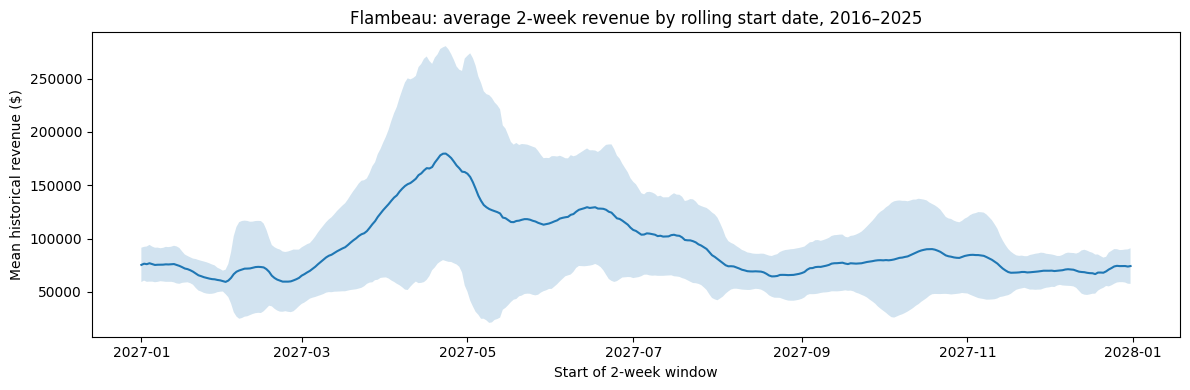

In [12]:
import matplotlib.pyplot as plt

wc_plot = window_curve[window_curve["month_day"] != "02-29"].sort_values("month_day").copy()
wc_plot["plot_date"] = pd.to_datetime("2027-" + wc_plot["month_day"], format="%Y-%m-%d")

plt.figure(figsize=(12, 4))
plt.plot(wc_plot["plot_date"], wc_plot["mean"])
plt.fill_between(wc_plot["plot_date"], wc_plot["mean"] - wc_plot["std"], wc_plot["mean"] + wc_plot["std"], alpha=0.2)
plt.xlabel("Start of 2-week window")
plt.ylabel("Mean historical revenue ($)")
plt.title("Flambeau: average 2-week revenue by rolling start date, 2016–2025")
plt.tight_layout()
plt.show()

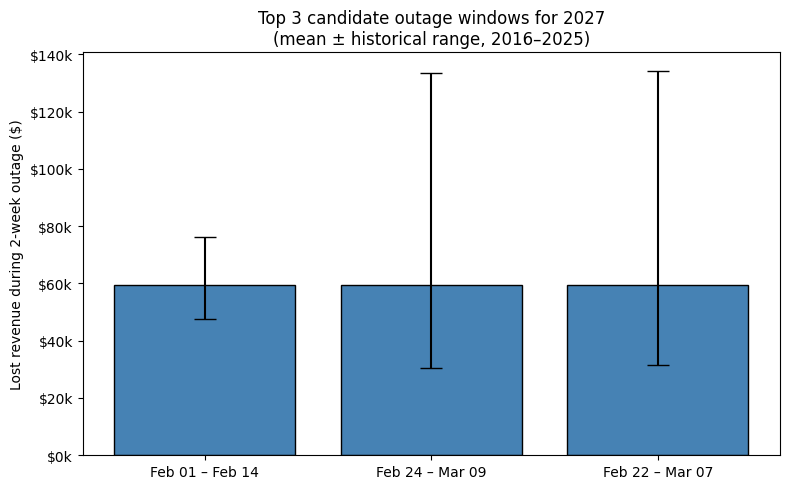

In [13]:
import matplotlib.pyplot as plt

labels = []
means = []
lower_err = []
upper_err = []

for _, row in top3.iterrows():
    start, end = month_day_to_2027(row["month_day"])
    labels.append(f"{start:%b %d} – {end:%b %d}")
    means.append(row["mean"])
    lower_err.append(row["mean"] - row["min"])
    upper_err.append(row["max"] - row["mean"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    labels,
    means,
    yerr=[lower_err, upper_err],
    capsize=8,
    color="steelblue",
    edgecolor="black",
)
ax.set_ylabel("Lost revenue during 2-week outage ($)")
ax.set_title("Top 3 candidate outage windows for 2027\n(mean ± historical range, 2016–2025)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
plt.tight_layout()
plt.show()